In [ ]:
!rm -rf dataset_raw output_dataset
!unzip -q archive.zip -d dataset_raw
!pip install -q split-folders

import splitfolders

splitfolders.ratio(
    "dataset_raw/facemask-dataset/dataset",
    output="output_dataset",
    seed=42,
    ratio=(0.7, 0.2, 0.1)
)

Copying files: 3833 files [00:00, 5462.47 files/s]


In [ ]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "output_dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "output_dataset/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "output_dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names
print(class_names)

Found 2682 files belonging to 2 classes.
Found 766 files belonging to 2 classes.
Found 385 files belonging to 2 classes.
['with_mask', 'without_mask']


In [ ]:
normalization = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization(x), y)).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (normalization(x), y)).prefetch(tf.data.AUTOTUNE)

In [ ]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Min pixel value:", images.numpy().min())
    print("Max pixel value:", images.numpy().max())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32, 1)
Min pixel value: 0.0
Max pixel value: 1.0


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Data augmentation (only active during training)
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.2, value_range=(0, 1)),
    layers.RandomContrast(0.2, value_range=(0, 1)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_2             │ (None, 128, 128, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_2               │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,624,385 (48.16 MB)

 Trainable params: 12,624,385 (48.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.8382 - loss: 0.3884 - val_accuracy: 0.8995 - val_loss: 0.2771
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8005 - loss: 0.4317 - val_accuracy: 0.8029 - val_loss: 0.4055
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.7092 - loss: 0.5228 - val_accuracy: 0.8825 - val_loss: 0.3836
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.7834 - loss: 0.4771 - val_accuracy: 0.8890 - val_loss: 0.4141
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.8210 - loss: 0.4298 - val_accuracy: 0.9034 - val_loss: 0.3090
Epoch 6/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.7733 - loss: 0.4572 - val_accuracy: 0.9034 - val_loss: 0.2637
Epoch 7/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.8035 - loss: 0.4040 - val_accuracy: 0.9230 - val_loss: 0.2753
Epoch 8/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.7673 - loss: 0.4462 - val_accuracy: 0.9191 - v

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8987 - loss: 0.2745
Test loss: 0.2745
Test accuracy: 0.8987


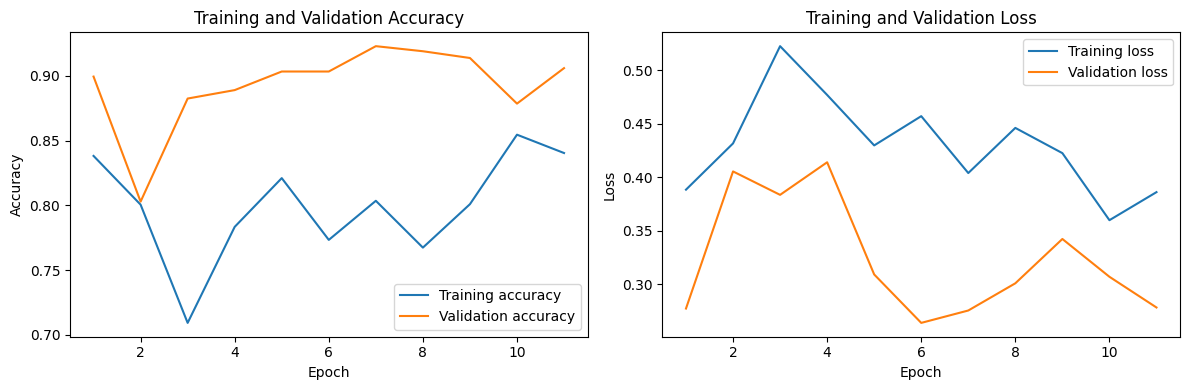

In [ ]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training accuracy")
plt.plot(epochs_range, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training loss")
plt.plot(epochs_range, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(128, 128))
    arr = tf.keras.utils.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    p = model.predict(arr, verbose=0)[0][0]
    label = "Without Mask" if p > 0.5 else "With Mask"
    conf = p if p > 0.5 else 1 - p

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{label} ({conf * 100:.1f}% confident)")
    plt.show()